# U04 — Deteccion de comportamiento sospechoso (XP imposible, automatizacion)

**Escenario:** Detectar eventos de ganancia de XP que resultan sospechosos: valores
imposiblemente altos, sesiones anormalmente cortas/largas, o patrones de eventos
consecutivos demasiado rapidos (posible automatizacion / scripting / explotacion de bugs).

Este es un problema de **deteccion de anomalias no supervisada**: en produccion no
tendriamos etiquetas de "esto es un fraude". Para poder *validar* el enfoque, el
simulador (`simulation/generate_dataset.py`) inyecto una columna de control
`is_anomaly_injected` que marca los eventos que el propio simulador genero como
outliers deliberados. **Esta columna NUNCA se usa como feature ni para entrenar el
modelo** — solo se usa, al final, para medir que tan bien el modelo no supervisado
recupera esos casos sinteticos. En un despliegue real esta columna no existiria.

## Distincion fit/holdout vs train/test supervisado
Como no hay etiquetas para entrenar, no hace un "train/test" clasico donde el modelo
aprende de `y`. En su lugar hacemos un split aleatorio 80/20 (`random_state=2026`)
en un conjunto **fit** (para ajustar el detector) y uno **holdout** (para verificar
que las tasas de anomalias detectadas sean *estables* entre ambos subconjuntos, es
decir, que el modelo no este sobreajustado a particularidades de una muestra). No es
una medicion de accuracy contra un target, sino un chequeo de estabilidad del modelo.


In [1]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

# nbconvert ejecuta el kernel con cwd = carpeta del notebook (notebooks/unsupervised);
# nos posicionamos en la raiz del repo para que las rutas relativas ("data/...", "models/...") funcionen.
if (Path.cwd() / "data").exists() is False and (Path.cwd().parents[1] / "data").exists():
    os.chdir(Path.cwd().parents[1])
print("cwd:", Path.cwd())

sns.set_theme(style="whitegrid")
RANDOM_STATE = 2026
pd.set_option("display.max_columns", 20)

xp = pd.read_csv("data/processed/xp_events.csv")
print(xp.shape)
xp.head()


cwd: C:\Users\tass1\Videos\tutunakun\tutunakun
(40270, 9)


,event_id,user_id,timestamp,source,xp_gained,session_duration_seconds,is_anomaly_injected,seconds_since_prev_event,events_last_hour_user
0,1549,1,2026-01-11 09:46:02,exercise,11.0,54.3,False,9999.0,1
1,12668,1,2026-01-14 18:56:50,exercise,11.0,46.0,False,292248.0,1
2,39960,1,2026-01-17 16:20:04,exercise,8.0,36.9,False,249794.0,1
3,30953,1,2026-01-17 21:06:05,daily_bonus,14.0,3.0,False,17161.0,1
4,39578,1,2026-01-22 18:40:15,exercise,10.0,49.0,False,423250.0,1


## 1. Exploracion de datos (EDA)

In [2]:
xp.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,40270.0,NaN,NaN,NaN,20135.5,11625.092007,1.0,10068.25,20135.5,30202.75,40270.0
user_id,40270.0,NaN,NaN,NaN,411.997566,232.604623,1.0,210.0,417.0,618.0,800.0
timestamp,40270,40189,2026-02-12 21:39:13,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,40270,5,exercise,22263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xp_gained,40270.0,NaN,NaN,NaN,32.520164,100.513363,4.0,10.0,13.0,35.0,1998.0
session_duration_seconds,40270.0,NaN,NaN,NaN,35.026744,15.01908,2.0,24.7,35.0,45.2,92.6
is_anomaly_injected,40270,2,False,39760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seconds_since_prev_event,40270.0,NaN,NaN,NaN,194970.101564,259463.136669,1.0,40127.0,107489.0,244001.25,3921378.0
events_last_hour_user,40270.0,NaN,NaN,NaN,1.175093,2.181287,1.0,1.0,1.0,1.0,57.0


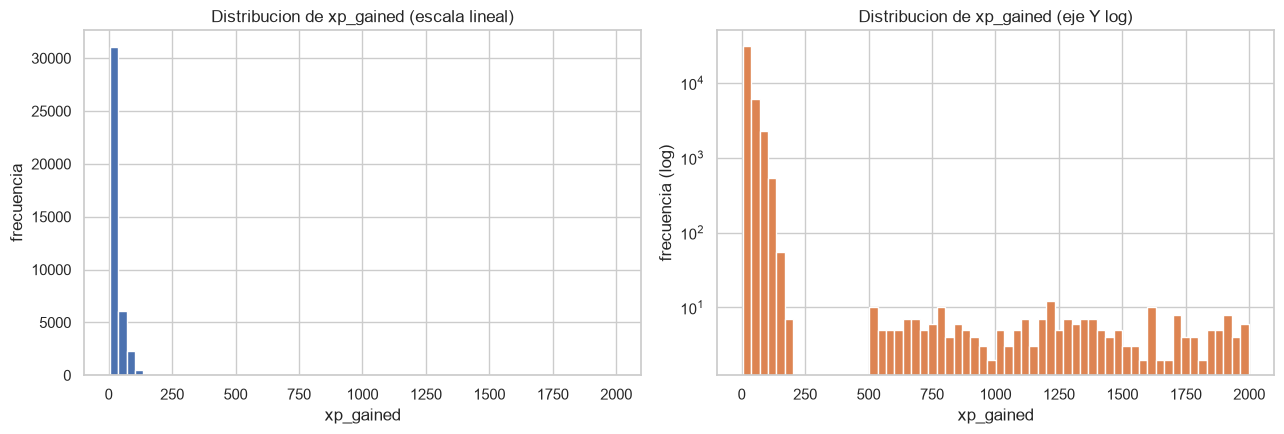

count    40270.000000
mean        32.520164
std        100.513363
min          4.000000
25%         10.000000
50%         13.000000
75%         35.000000
max       1998.000000
Name: xp_gained, dtype: float64
Percentil 99: 124.0
Percentil 99.9: 1725.923999999999


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(xp["xp_gained"], bins=60, color="#4C72B0")
axes[0].set_title("Distribucion de xp_gained (escala lineal)")
axes[0].set_xlabel("xp_gained")
axes[0].set_ylabel("frecuencia")

axes[1].hist(xp["xp_gained"], bins=60, color="#DD8452")
axes[1].set_yscale("log")
axes[1].set_title("Distribucion de xp_gained (eje Y log)")
axes[1].set_xlabel("xp_gained")
axes[1].set_ylabel("frecuencia (log)")
plt.tight_layout()
plt.show()

print(xp["xp_gained"].describe())
print("Percentil 99:", xp["xp_gained"].quantile(0.99))
print("Percentil 99.9:", xp["xp_gained"].quantile(0.999))


**Interpretacion:** la mayoria de los eventos otorgan XP en un rango bajo
(mediana ~13, p75 ~35), pero existe una cola pesada que llega hasta ~2000 XP en un
solo evento. Ese tipo de valores no son plausibles para una accion normal (ejercicio,
leccion, bono) y son justamente el tipo de "XP imposible" que el detector debe
aprender a aislar como region de baja densidad, sin que se le diga explicitamente
donde esta el corte.

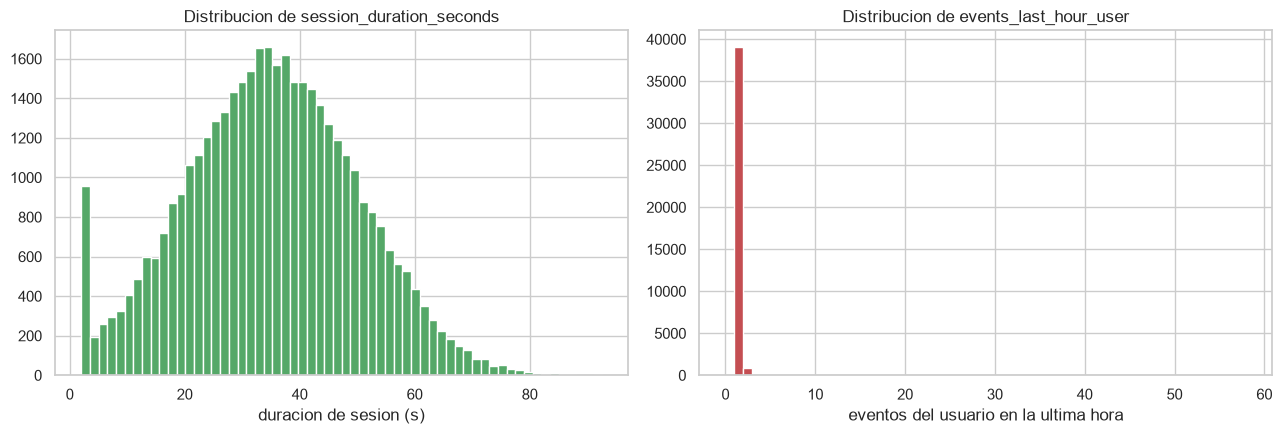

,session_duration_seconds,events_last_hour_user,seconds_since_prev_event
count,40270.000000,40270.000000,4.027000e+04
mean,35.026744,1.175093,1.949701e+05
std,15.019080,2.181287,2.594631e+05
min,2.000000,1.000000,1.000000e+00
25%,24.700000,1.000000,4.012700e+04
50%,35.000000,1.000000,1.074890e+05
75%,45.200000,1.000000,2.440012e+05
max,92.600000,57.000000,3.921378e+06


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(xp["session_duration_seconds"], bins=60, color="#55A868")
axes[0].set_title("Distribucion de session_duration_seconds")
axes[0].set_xlabel("duracion de sesion (s)")

axes[1].hist(xp["events_last_hour_user"], bins=range(0, int(xp["events_last_hour_user"].max()) + 2), color="#C44E52")
axes[1].set_title("Distribucion de events_last_hour_user")
axes[1].set_xlabel("eventos del usuario en la ultima hora")
plt.tight_layout()
plt.show()

xp[["session_duration_seconds", "events_last_hour_user", "seconds_since_prev_event"]].describe()


**Interpretacion:** `session_duration_seconds` muy bajas (sesiones casi
instantaneas que aun asi otorgan XP) combinadas con `events_last_hour_user` muy altos
(muchos eventos por hora) son indicios tipicos de automatizacion/scripting. Estas tres
variables, junto con `xp_gained`, forman el espacio de features para el detector.

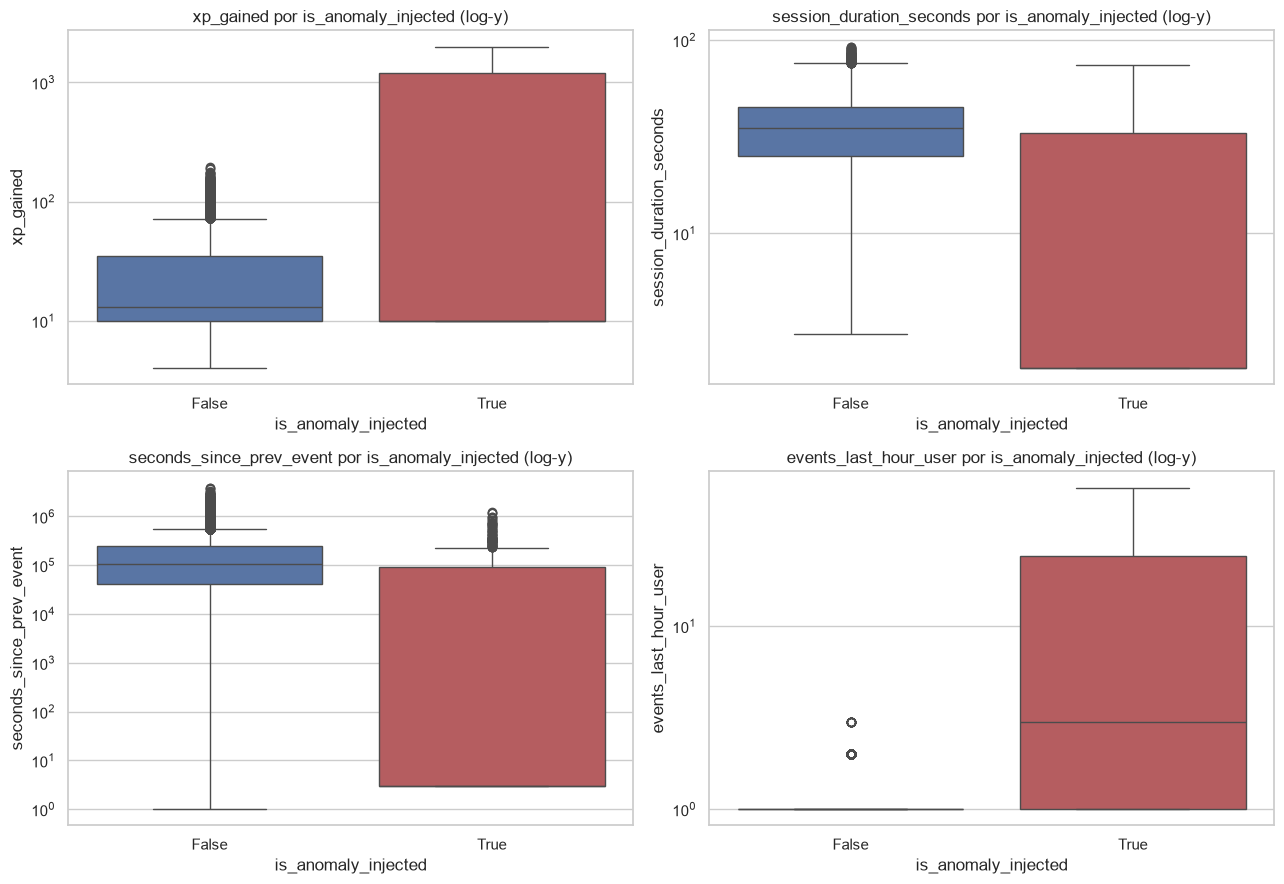

In [5]:
comparison_cols = ["xp_gained", "session_duration_seconds", "seconds_since_prev_event", "events_last_hour_user"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), comparison_cols):
    sns.boxplot(data=xp, x="is_anomaly_injected", y=col, ax=ax, hue="is_anomaly_injected",
                palette={False: "#4C72B0", True: "#C44E52"}, legend=False)
    ax.set_yscale("log")
    ax.set_title(f"{col} por is_anomaly_injected (log-y)")
plt.tight_layout()
plt.show()


**Nota importante:** esta comparacion contra `is_anomaly_injected` es posible
*solo porque* controlamos la simulacion y sabemos que casos fueron inyectados como
outliers deliberados. Se usa exclusivamente para **interpretar/validar** visualmente
si las anomalias inyectadas realmente se separan de la poblacion normal en estas
variables — nunca se le pasa esta columna al modelo como input. En un despliegue real
no existiria esta etiqueta y la validacion se haria con revision manual / feedback de
soporte.

## 2. Split fit / holdout (80/20, no supervisado)

In [6]:
feature_cols = ["xp_gained", "session_duration_seconds", "seconds_since_prev_event", "events_last_hour_user"]

fit_df, holdout_df = train_test_split(xp, test_size=0.2, random_state=RANDOM_STATE)
print("fit:", fit_df.shape, " holdout:", holdout_df.shape)
print("tasa is_anomaly_injected en fit:", fit_df["is_anomaly_injected"].mean().round(4))
print("tasa is_anomaly_injected en holdout:", holdout_df["is_anomaly_injected"].mean().round(4))


fit: (32216, 9)  holdout: (8054, 9)
tasa is_anomaly_injected en fit: 0.0124
tasa is_anomaly_injected en holdout: 0.0135


## 3. Modelos candidatos

Se comparan varias configuraciones de `IsolationForest` y una alternativa
`OneClassSVM`. Cada pipeline es `StandardScaler` + detector. Ninguno ve
`is_anomaly_injected` durante el ajuste. Cada modelo se ajusta sobre el conjunto
**fit** y luego se evalua produciendo etiquetas para el **dataset completo**
(fit+holdout), lo cual nos permite (a) revisar estabilidad fit vs holdout y (b)
comparar contra la etiqueta inyectada como validacion externa.

Convencion de salida (`sklearn`): `predict()` devuelve **-1 = anomalia**, **1 =
normal**, tanto para `IsolationForest` como para `OneClassSVM`.

In [7]:
def evaluate_against_injected(y_true_injected, pred_labels, name):
    # pred_labels: -1 anomaly / 1 normal -> convertir a booleano "es_anomalia"
    pred_is_anomaly = pred_labels == -1
    precision = precision_score(y_true_injected, pred_is_anomaly, zero_division=0)
    recall = recall_score(y_true_injected, pred_is_anomaly, zero_division=0)
    f1 = f1_score(y_true_injected, pred_is_anomaly, zero_division=0)
    n_flagged = pred_is_anomaly.sum()
    print(f"[{name}] flagged={n_flagged} ({n_flagged/len(pred_labels):.3%})  "
          f"precision={precision:.3f}  recall={recall:.3f}  f1={f1:.3f}")
    return {"precision": precision, "recall": recall, "f1": f1, "n_flagged": int(n_flagged)}

candidates = {}

candidates["iforest_c02_n100"] = Pipeline([
    ("scaler", StandardScaler()),
    ("iforest", IsolationForest(n_estimators=100, contamination=0.02, random_state=RANDOM_STATE)),
])
candidates["iforest_c05_n300"] = Pipeline([
    ("scaler", StandardScaler()),
    ("iforest", IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE)),
])
candidates["ocsvm_nu03"] = Pipeline([
    ("scaler", StandardScaler()),
    ("ocsvm", OneClassSVM(kernel="rbf", gamma="scale", nu=0.03)),
])

results = {}
fitted_pipelines = {}
for name, pipe in candidates.items():
    pipe.fit(fit_df[feature_cols])
    fitted_pipelines[name] = pipe

    pred_fit = pipe.predict(fit_df[feature_cols])
    pred_holdout = pipe.predict(holdout_df[feature_cols])
    rate_fit = (pred_fit == -1).mean()
    rate_holdout = (pred_holdout == -1).mean()
    print(f"--- {name} --- anomaly-rate fit={rate_fit:.3%}  holdout={rate_holdout:.3%}  |diff|={abs(rate_fit-rate_holdout):.3%}")

    pred_full = pipe.predict(xp[feature_cols])
    results[name] = evaluate_against_injected(xp["is_anomaly_injected"].values, pred_full, name)


--- iforest_c02_n100 --- anomaly-rate fit=1.996%  holdout=2.098%  |diff|=0.102%


[iforest_c02_n100] flagged=812 (2.016%)  precision=0.536  recall=0.853  f1=0.658


--- iforest_c05_n300 --- anomaly-rate fit=5.001%  holdout=4.942%  |diff|=0.059%


[iforest_c05_n300] flagged=2009 (4.989%)  precision=0.251  recall=0.988  f1=0.400


--- ocsvm_nu03 --- anomaly-rate fit=2.999%  holdout=2.918%  |diff|=0.081%


[ocsvm_nu03] flagged=1201 (2.982%)  precision=0.422  recall=0.994  f1=0.593


**Como leer la comparacion:** dado que la etiqueta inyectada existe solo por
tratarse de datos simulados, aqui la tratamos *como si* fuera un chequeo de
clasificacion binaria: "flagged como anomalia" vs "fue inyectado como anomalia por el
simulador". Es una forma legitima de validar detectores no supervisados cuando se
dispone de datos sinteticos con ground-truth controlado; el F1 resultante sirve para
elegir la configuracion ganadora, aunque en produccion (sin ground-truth) la eleccion
final de `contamination`/`nu` se apoyaria mas en criterio de negocio.

In [8]:
results_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
results_df


,precision,recall,f1,n_flagged
iforest_c02_n100,0.535714,0.852941,0.658094,812.0
ocsvm_nu03,0.422148,0.994118,0.592636,1201.0
iforest_c05_n300,0.250871,0.988235,0.400159,2009.0


In [9]:
winner_name = results_df.index[0]
winner_pipeline_probe = fitted_pipelines[winner_name]
print("Modelo ganador:", winner_name)
print(results_df.loc[winner_name])


Modelo ganador: iforest_c02_n100
precision      0.535714
recall         0.852941
f1             0.658094
n_flagged    812.000000
Name: iforest_c02_n100, dtype: float64


## 4. Matriz de confusion y visualizacion del modelo ganador

                flagged=False  flagged=True
injected=False          39383           377
injected=True              75           435


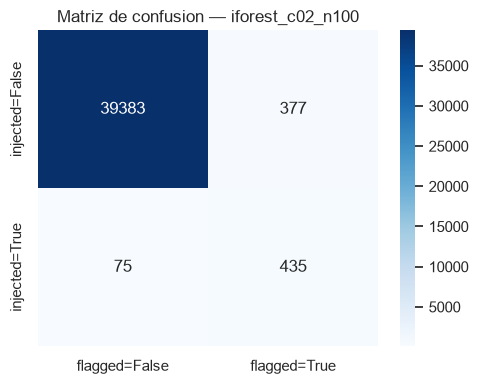

In [10]:
pred_full_winner = winner_pipeline_probe.predict(xp[feature_cols])
pred_is_anomaly_winner = pred_full_winner == -1

cm = confusion_matrix(xp["is_anomaly_injected"], pred_is_anomaly_winner, labels=[False, True])
cm_df = pd.DataFrame(cm, index=["injected=False", "injected=True"], columns=["flagged=False", "flagged=True"])
print(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title(f"Matriz de confusion — {winner_name}")
plt.tight_layout()
plt.show()


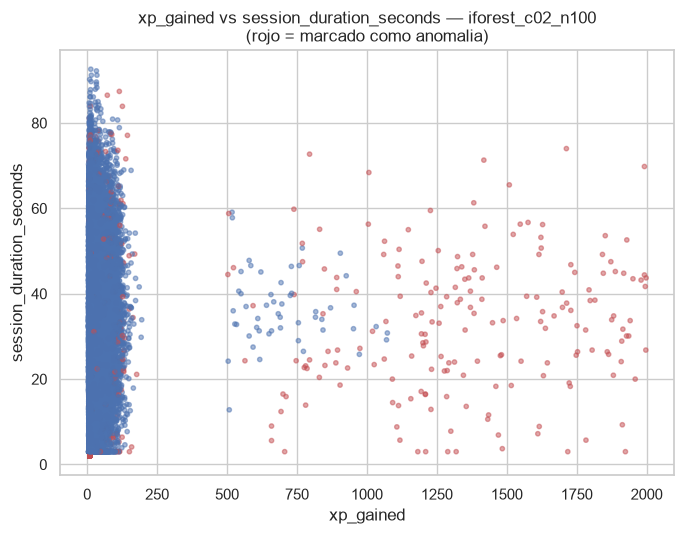

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = np.where(pred_is_anomaly_winner, "#C44E52", "#4C72B0")
ax.scatter(xp["xp_gained"], xp["session_duration_seconds"], c=colors, s=10, alpha=0.5)
ax.set_xlabel("xp_gained")
ax.set_ylabel("session_duration_seconds")
ax.set_title(f"xp_gained vs session_duration_seconds — {winner_name}\n(rojo = marcado como anomalia)")
plt.tight_layout()
plt.show()


## 5. Entrenamiento final y exportacion del artefacto

In [12]:
# Refit del pipeline ganador sobre el dataset COMPLETO para el artefacto de despliegue
if winner_name == "iforest_c02_n100":
    final_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("iforest", IsolationForest(n_estimators=100, contamination=0.02, random_state=RANDOM_STATE)),
    ])
    algorithm_name = "IsolationForest(n_estimators=100, contamination=0.02)"
elif winner_name == "iforest_c05_n300":
    final_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("iforest", IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE)),
    ])
    algorithm_name = "IsolationForest(n_estimators=300, contamination=0.05)"
else:
    final_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(kernel="rbf", gamma="scale", nu=0.03)),
    ])
    algorithm_name = "OneClassSVM(kernel=rbf, nu=0.03)"

final_pipeline.fit(xp[feature_cols])

final_pred = final_pipeline.predict(xp[feature_cols])
final_metrics = evaluate_against_injected(xp["is_anomaly_injected"].values, final_pred, f"FINAL ({winner_name})")


[FINAL (iforest_c02_n100)] flagged=806 (2.001%)  precision=0.502  recall=0.794  f1=0.616


In [13]:
import os
os.makedirs("models/serialized", exist_ok=True)

joblib.dump({"pipeline": final_pipeline}, "models/serialized/anomaly_detector.joblib")

metadata = {
    "model_name": "anomaly_detector",
    "version": "1.0.0",
    "algorithm": algorithm_name,
    "task": "anomaly_detection",
    "features": feature_cols,
    "metrics": {
        "precision_vs_injected": final_metrics["precision"],
        "recall_vs_injected": final_metrics["recall"],
        "f1_vs_injected": final_metrics["f1"],
    },
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "notes": (
        "Pipeline = StandardScaler + detector no supervisado. predict() devuelve "
        "-1 para anomalia y 1 para normal (convencion sklearn). Para un score de "
        "confianza continuo usar decision_function() (mas negativo = mas anomalo) "
        "o score_samples() si el estimador final lo soporta (IsolationForest si; "
        "OneClassSVM solo decision_function). is_anomaly_injected fue usado UNICAMENTE "
        "para calcular las metricas de validacion externa, nunca como feature de entrenamiento."
    ),
}
with open("models/serialized/anomaly_detector_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(json.dumps(metadata, indent=2, ensure_ascii=False))


{
  "model_name": "anomaly_detector",
  "version": "1.0.0",
  "algorithm": "IsolationForest(n_estimators=100, contamination=0.02)",
  "task": "anomaly_detection",
  "features": [
    "xp_gained",
    "session_duration_seconds",
    "seconds_since_prev_event",
    "events_last_hour_user"
  ],
  "metrics": {
    "precision_vs_injected": 0.5024813895781638,
    "recall_vs_injected": 0.7941176470588235,
    "f1_vs_injected": 0.6155015197568389
  },
  "trained_at": "2026-08-01T01:10:15.234317+00:00",
  "notes": "Pipeline = StandardScaler + detector no supervisado. predict() devuelve -1 para anomalia y 1 para normal (convencion sklearn). Para un score de confianza continuo usar decision_function() (mas negativo = mas anomalo) o score_samples() si el estimador final lo soporta (IsolationForest si; OneClassSVM solo decision_function). is_anomaly_injected fue usado UNICAMENTE para calcular las metricas de validacion externa, nunca como feature de entrenamiento."
}


## 6. Verificacion final: recargar el artefacto y probar con casos sinteticos

In [14]:
loaded = joblib.load("models/serialized/anomaly_detector.joblib")
loaded_pipeline = loaded["pipeline"]

real_sample = xp[feature_cols].sample(5, random_state=RANDOM_STATE).reset_index(drop=True)

synthetic_anomalous = pd.DataFrame({
    "xp_gained": [1500.0, 1800.0],
    "session_duration_seconds": [2.0, 1.0],
    "seconds_since_prev_event": [1.0, 0.5],
    "events_last_hour_user": [40, 55],
})

synthetic_normal = pd.DataFrame({
    "xp_gained": [12.0, 18.0],
    "session_duration_seconds": [32.0, 45.0],
    "seconds_since_prev_event": [45000.0, 120000.0],
    "events_last_hour_user": [1, 2],
})

real_sample = real_sample.assign(case_type="real")
synthetic_anomalous = synthetic_anomalous.assign(case_type="synthetic_anomalous")
synthetic_normal = synthetic_normal.assign(case_type="synthetic_normal")

probe_df = pd.concat([real_sample, synthetic_anomalous, synthetic_normal], ignore_index=True)

X_probe = probe_df[feature_cols]
labels = loaded_pipeline.predict(X_probe)
probe_df["predicted_label"] = labels
probe_df["predicted_is_anomaly"] = labels == -1

final_estimator = loaded_pipeline.named_steps[list(loaded_pipeline.named_steps)[-1]]
if hasattr(loaded_pipeline, "decision_function"):
    probe_df["decision_function"] = loaded_pipeline.decision_function(X_probe)
if hasattr(final_estimator, "score_samples") and hasattr(loaded_pipeline, "score_samples"):
    try:
        probe_df["score_samples"] = loaded_pipeline.score_samples(X_probe)
    except Exception as exc:
        print("score_samples no disponible:", exc)

probe_df


,xp_gained,session_duration_seconds,seconds_since_prev_event,events_last_hour_user,case_type,predicted_label,predicted_is_anomaly,decision_function,score_samples
0,64.0,50.8,57351.0,1,real,1,False,0.198025,-0.416231
1,10.0,2.0,3.0,18,real,-1,True,-0.092497,-0.706753
2,11.0,34.9,16955.0,1,real,1,False,0.251103,-0.363154
3,14.0,44.3,95676.0,1,real,1,False,0.260556,-0.353701
4,10.0,62.2,736280.0,1,real,1,False,0.100505,-0.513751
5,1500.0,2.0,1.0,40,synthetic_anomalous,-1,True,-0.198195,-0.812452
6,1800.0,1.0,0.5,55,synthetic_anomalous,-1,True,-0.210252,-0.824509
7,12.0,32.0,45000.0,1,synthetic_normal,1,False,0.255553,-0.358704
8,18.0,45.0,120000.0,2,synthetic_normal,1,False,0.065103,-0.549154


**Resultado esperado:** las dos filas `synthetic_anomalous` (XP extremo,
sesion casi instantanea, altisima frecuencia de eventos) deben quedar marcadas con
`predicted_label = -1` (anomalia), mientras que las `synthetic_normal` y la mayoria de
las filas `real` deben quedar en `predicted_label = 1` (normal), confirmando que el
artefacto exportado es directamente usable para scoring en produccion.